A notebook for determining and visualizing surgery coordinates!  
All coordinates are with reference to bregma  
  
  Use the brainglobe-env with brainglobe-atlasapi

In [4]:
import numpy as np
import matplotlib.pyplot as plt
from brainglobe_atlasapi import BrainGlobeAtlas

In [14]:
"""Where do we want to go?"""
# VTA
# AP = -3.52
# ML = -0.35
# DV = -4

# DRN
AP = -4.55
ML = 0.0
DV = -2.9

"""What angle do we want to use?"""
ML_theta = 0 # in degrees
AP_theta = 20 # in degrees
assert np.logical_or(ML_theta == 0, AP_theta == 0), "Only one angle can be non-zero at a time"

In [ ]:
"""New coordinates of the target point after rotation"""
if ML_theta != 0:
    DV_new = -(np.abs(DV)/np.cos(np.radians(ML_theta))) # hypotenuse
    AP_new = AP
    ML_new = (np.abs(ML) + (np.abs(DV_new) * np.sin(np.radians(ML_theta)))) # opposite
    ML_new = ML_new * np.sign(ML) if np.sign(ML) != 0 else ML_new # restore sign of ML
elif AP_theta != 0:
    DV_new = -(np.abs(DV)/np.cos(np.radians(AP_theta))) #
    AP_new = (np.abs(AP) + (np.abs(DV_new) * np.sin(np.radians(AP_theta)))) # opposite
    AP_new = AP_new * np.sign(AP) if np.sign(AP) != 0 else AP_new # restore sign of AP
print(f"New coordinates with respect to bregmafor drilling considering an angle of {ML_theta if ML_theta != 0 else AP_theta} degrees: AP = {AP_new:.2f}, ML = {ML_new:.2f}")

"""New coordinates for injecting to the target point at an angle"""
if ML_theta != 0:
    DV_inj = -(np.abs(DV_new) - (np.sin(np.radians(ML_theta)) * np.abs(ML_new)))
    AP_inj = AP_new
    ML_inj = np.cos(np.radians(ML_theta)) * ML_new
elif AP_theta != 0:
    DV_inj = -(np.abs(DV_new) - (np.sin(np.radians(AP_theta)) * np.abs(AP_new)))
    AP_inj = np.cos(np.radians(AP_theta)) * AP_new
    ML_inj = ML_new
print(f"New coordinates with respect to bregma for injection at an angle of {ML_theta if ML_theta != 0 else AP_theta} degrees: AP = {AP_inj:.2f}, ML = {ML_inj:.2f}, DV = {DV_inj:.2f}")

"""ML leveling coordinates"""
ML_distance = 2 # in mm, total left to right distance between points
print(f"Depth difference between left and right leveling points at {ML_distance} mm apart:")
for i in [-1, 0, 1]:
    depth_diff = np.sin(np.radians(ML_theta + i)) * ML_distance
    print(f"At an angle of {ML_theta + i} degrees: {depth_diff:.2f} mm")

"""AP leveling coordinates"""
AP_distance = 2 # in mm, total top to bottom distance between points
print(f"Depth difference between top and bottom leveling points at {AP_distance} mm apart:")
for i in [-1, 0, 1]:
    depth_diff = np.sin(np.radians(AP_theta + i)) * AP_distance
    print(f"At an angle of {AP_theta + i} degrees: {depth_diff:.2f} mm")

New coordinates with respect to bregmafor drilling considering an angle of 0 degrees: AP = -5.61, ML = 1.06
New coordinates with respect to bregma for injection at an angle of 0 degrees: AP = -5.27, ML = 1.06, DV = -1.17
Depth difference between left and right leveling points at 2 mm apart:
At an angle of -1 degrees: -0.03 mm
At an angle of 0 degrees: 0.00 mm
At an angle of 1 degrees: 0.03 mm
Depth difference between top and bottom leveling points at 2 mm apart:
At an angle of 19 degrees: 0.65 mm
At an angle of 20 degrees: 0.68 mm
At an angle of 21 degrees: 0.72 mm


In [19]:
atlas.annotation.shape

(528, 320, 456)

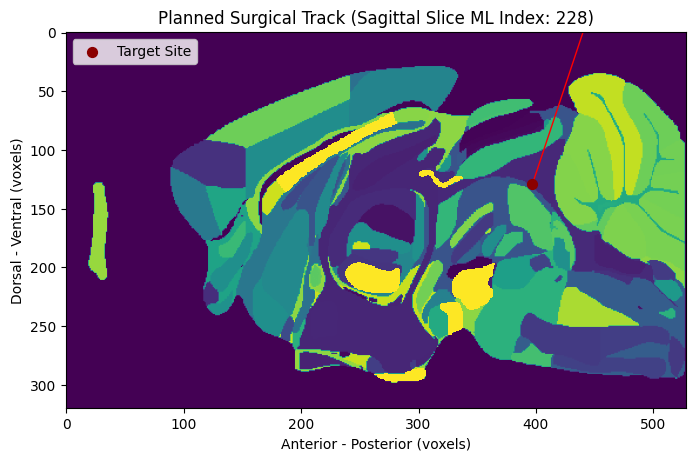

In [21]:
"""Draw the coordinates!"""
atlas = BrainGlobeAtlas("allen_mouse_25um")

# CCFv3.0 coordinates of bregma in voxel space
atlas_bregma_ap = 216
atlas_bregma_dv = 14
atlas_bregma_ml = 228

injection_voxel_ap = atlas_bregma_ap + int(-AP / .025) # if i want to be posterior (-ve) to bregma i need to add to the bregma index
injection_voxel_ml = atlas_bregma_ml + int(ML / .025)
injection_voxel_ml_new = atlas_bregma_ml + int(ML_new / .025)
injection_voxel_dv = atlas_bregma_dv + int(np.abs(DV) / .025)
injection_voxel_ap_new = atlas_bregma_ap + int(-AP_new / .025)

# draw the triangle to check
fig, ax = plt.subplots(figsize=(8, 6))
if ML_theta != 0:
    coronal_slice = atlas.annotation[injection_voxel_ap, :, :]
    ax.imshow(coronal_slice, vmax = 1200)
    # mark injection target
    ax.scatter(injection_voxel_ml, injection_voxel_dv, color="darkred", s=50, zorder=5, label="Target Site")
    # make line for injection angle
    ax.plot([injection_voxel_ml_new, injection_voxel_ml], [0, injection_voxel_dv], '-r', lw=1)
    ax.set_title(f"Planned Surgical Track (Coronal Slice AP Index: {injection_voxel_ap})")
    ax.set_xlabel("Medial - Lateral (voxels)")
    ax.set_ylabel("Dorsal - Ventral (voxels)")

if AP_theta != 0:
    sagittal_slice = atlas.annotation[:, :, injection_voxel_ml].T
    ax.imshow(sagittal_slice, vmax = 1200)
    # mark injection target
    ax.scatter(injection_voxel_ap, injection_voxel_dv, color="darkred", s=50, zorder=5, label="Target Site")
    # make line for injection angle
    ax.plot([injection_voxel_ap_new, injection_voxel_ap], [0, injection_voxel_dv], '-r', lw=1)
    ax.set_title(f"Planned Surgical Track (Sagittal Slice ML Index: {injection_voxel_ml})")
    ax.set_xlabel("Anterior - Posterior (voxels)")
    ax.set_ylabel("Dorsal - Ventral (voxels)")
plt.legend()
plt.show()